In [146]:
import pandas as pd
import numpy as np
df=pd.read_csv("raw_data.csv")
pd.set_option("display.width", 500)
print(df.head())


   student_id  age  gender  cgpa branch college_tier  internships_count  projects_count  certifications_count  coding_skill_score  ...  mock_interview_score  attendance_percentage  backlogs  extracurricular_score  leadership_score  volunteer_experience  sleep_hours  study_hours_per_day  placement_status  salary_package_lpa
0           1   24    Male  7.53     IT       Tier 2                  4               6                     1           99.238568  ...             72.647009              77.463863         2              63.382726         52.938240                   Yes          6.7                  3.6        Not Placed                0.00
1           2   21    Male  7.92    CSE       Tier 2                  1               3                     6           80.966123  ...             61.699110              88.887600         1              73.694605         60.198856                    No          4.4                  2.3        Not Placed                0.00
2           3   22  Femal

In [147]:

print(df.columns)

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status',
       'salary_package_lpa'],
      dtype='str')


In [148]:

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

In [149]:
df.drop(["student_id","gender","coding_skill_score","aptitude_score","logical_reasoning_score","hackathons_participated","github_repos","linkedin_connections","mock_interview_score","attendance_percentage","attendance_percentage","extracurricular_score","leadership_score","volunteer_experience","sleep_hours","study_hours_per_day"],axis=1,inplace=True)
df["communication_skill_score"]=np.round(df["communication_skill_score"],1)/10
df["communication_skill_score"]=np.round(df["communication_skill_score"],1)
print(df.columns)

Index(['age', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'communication_skill_score', 'backlogs', 'placement_status', 'salary_package_lpa'], dtype='str')


In [150]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        100000 non-null  int64  
 1   cgpa                       100000 non-null  float64
 2   branch                     100000 non-null  str    
 3   college_tier               100000 non-null  str    
 4   internships_count          100000 non-null  int64  
 5   projects_count             100000 non-null  int64  
 6   certifications_count       100000 non-null  int64  
 7   communication_skill_score  100000 non-null  float64
 8   backlogs                   100000 non-null  int64  
 9   placement_status           100000 non-null  str    
 10  salary_package_lpa         100000 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 8.4 MB
None


In [151]:
print(df.isnull().sum())
print("duplicated : ",df.duplicated().sum())

age                          0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
communication_skill_score    0
backlogs                     0
placement_status             0
salary_package_lpa           0
dtype: int64
duplicated :  4


In [152]:
print(df["branch"].value_counts())

branch
CSE           34818
IT            19999
ECE           14908
EEE           10177
Mechanical    10077
Civil         10021
Name: count, dtype: int64


dataset is free from missing values and duplicated

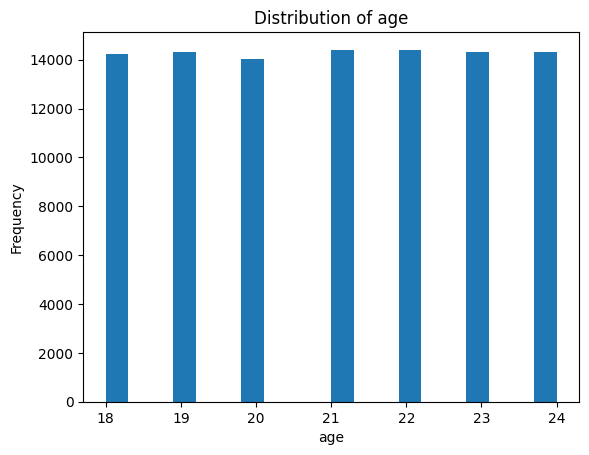

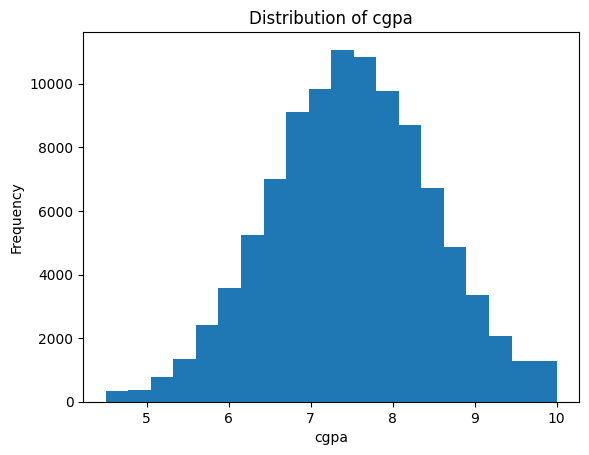

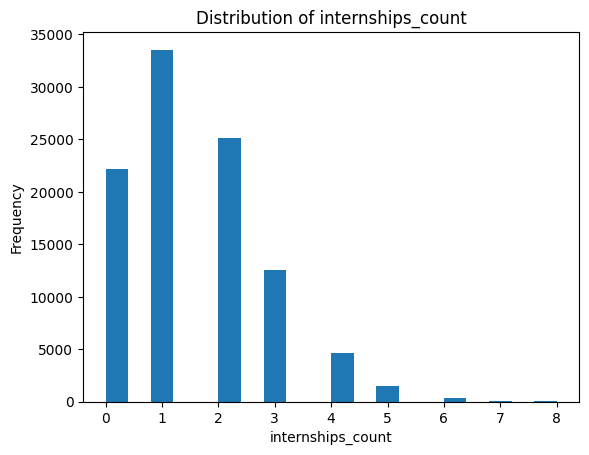

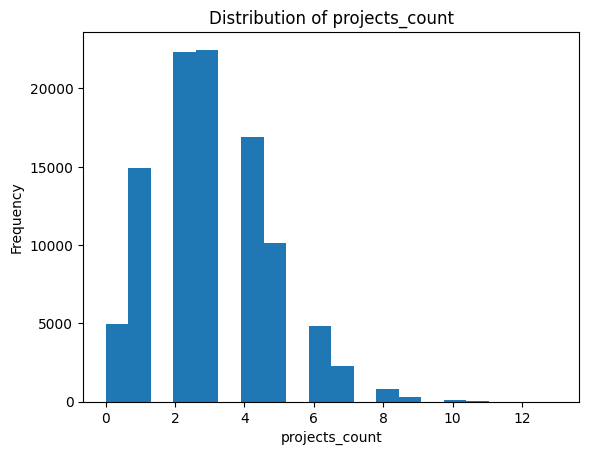

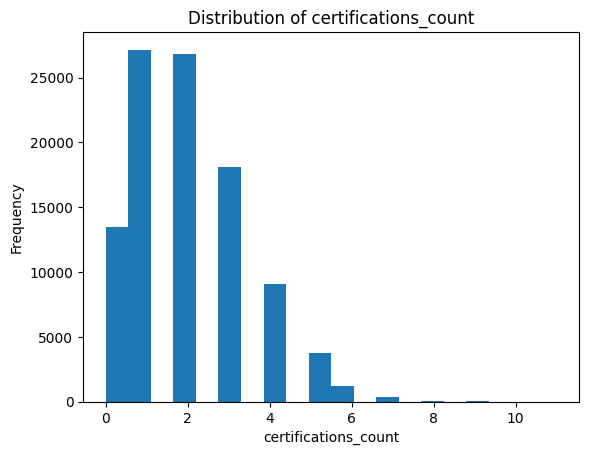

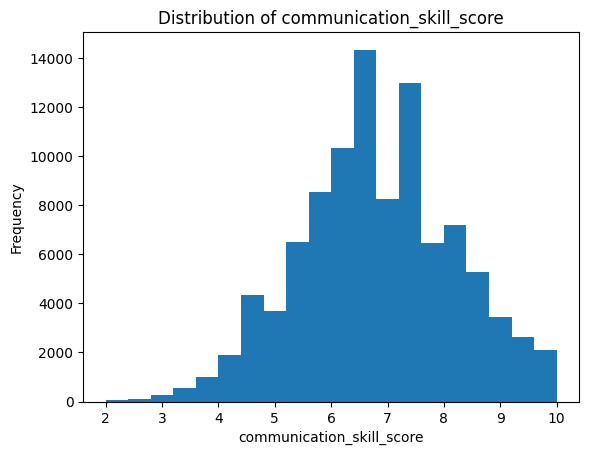

In [153]:
import matplotlib.pyplot as plt
df2=df.sample(5000)
num_cols = ['age','cgpa','internships_count',
            'projects_count','certifications_count',
            'communication_skill_score']

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


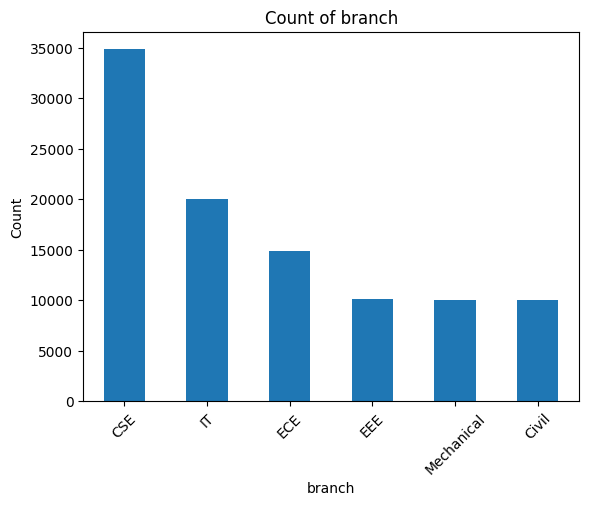

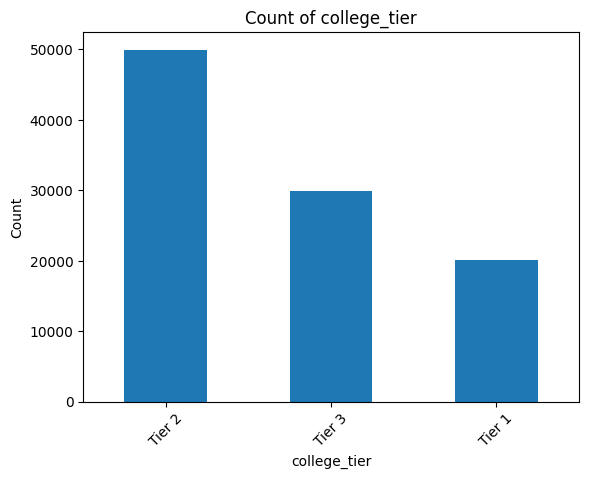

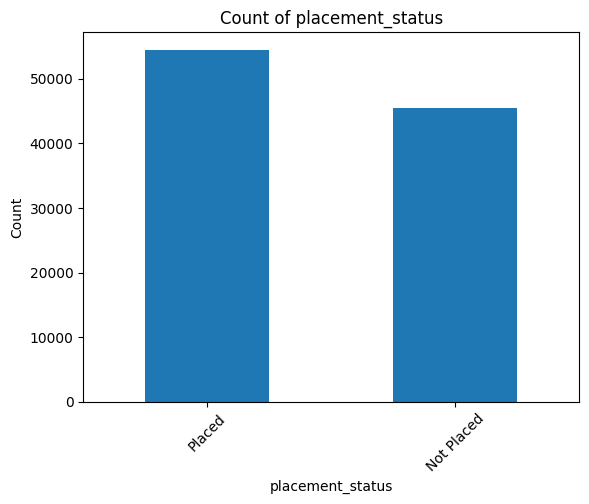

In [154]:
cat_cols = ['branch','college_tier','placement_status']

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

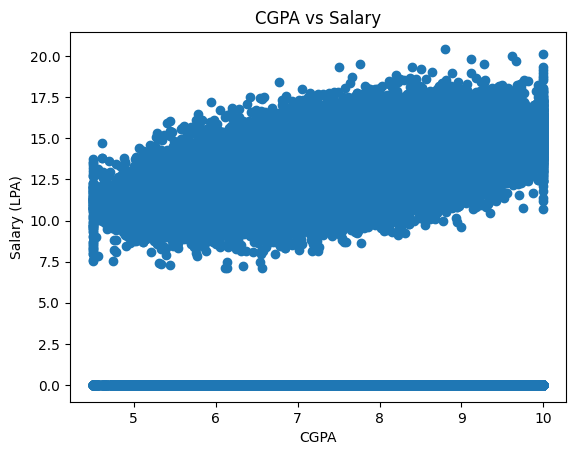

In [155]:
plt.figure()
plt.scatter(df['cgpa'], df['salary_package_lpa'])
plt.title('CGPA vs Salary')
plt.xlabel('CGPA')
plt.ylabel('Salary (LPA)')
plt.show()

** - "A higher CGPA is positively associated with higher salary packages, making academic performance an important factor in career outcomes."

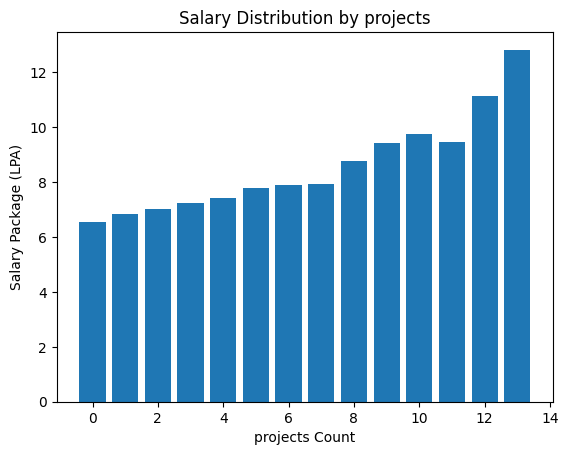

In [156]:
aa=df.groupby("projects_count")["salary_package_lpa"].mean()
plt.bar(aa.index,aa.values)
plt.xlabel('projects Count')
plt.ylabel('Salary Package (LPA)')
plt.title('Salary Distribution by projects')
plt.show()


** "More Project help to get higher Salary Packages."

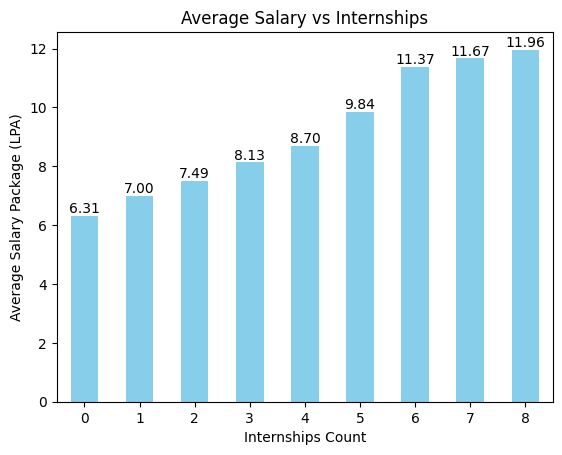

In [157]:
avg_salary = df.groupby('internships_count')['salary_package_lpa'].mean()
ax = avg_salary.plot(kind='bar', color='skyblue')

for i, v in enumerate(avg_salary):
    ax.text(i, v + 0.1, f"{v:.2f}", ha='center')

plt.xlabel('Internships Count')
plt.ylabel('Average Salary Package (LPA)')
plt.title('Average Salary vs Internships')
plt.xticks(rotation=0.1)
plt.show()

** "Internships help to get placement and it also help to get high Salary"

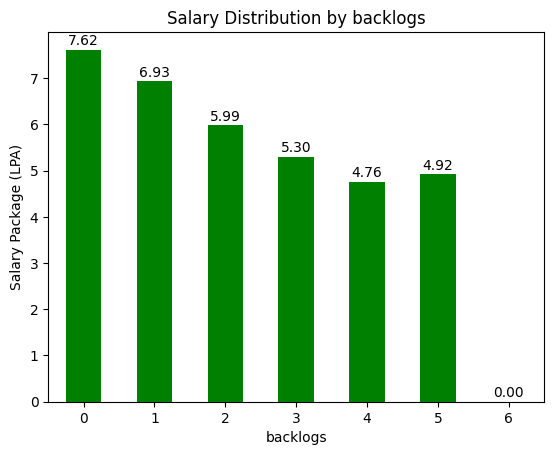

In [158]:
ab=df.groupby("backlogs")["salary_package_lpa"].mean()
ax2 = ab.plot(kind='bar', color='green')

for i, v in enumerate(ab):
    ax2.text(i, v + 0.1, f"{v:.2f}", ha='center')

plt.xlabel('backlogs')
plt.ylabel('Salary Package (LPA)')
plt.title('Salary Distribution by backlogs')
plt.xticks(rotation=0.1)
plt.show()


** "Backlogs affects on career and less backlogs help to get more salary."

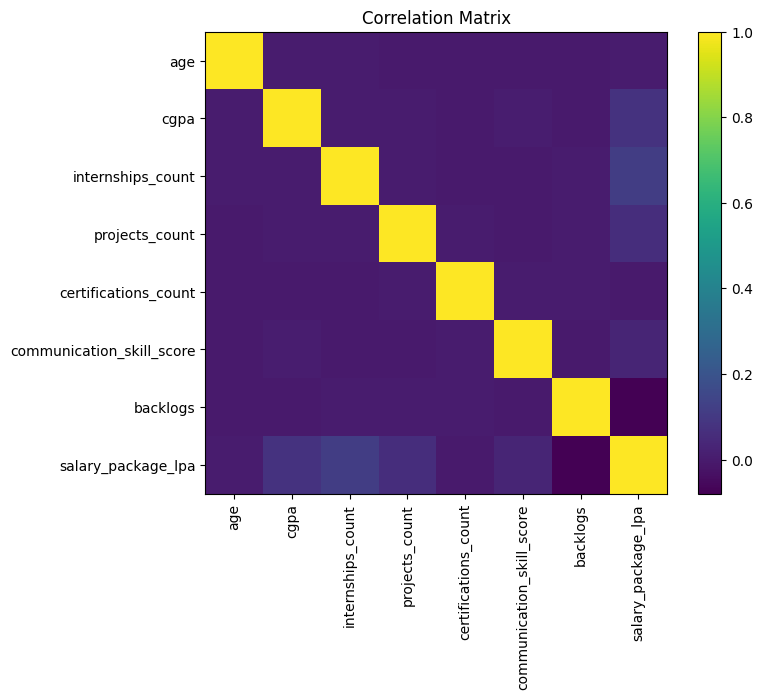

In [159]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

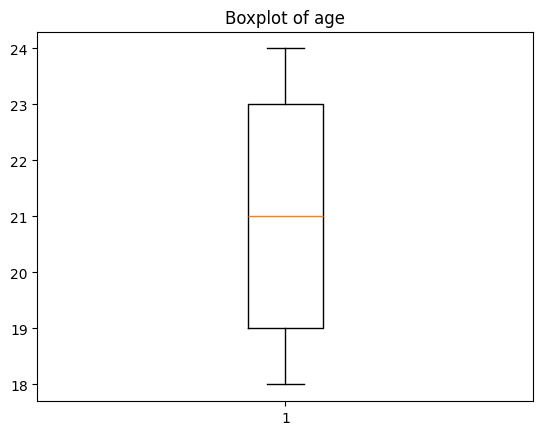

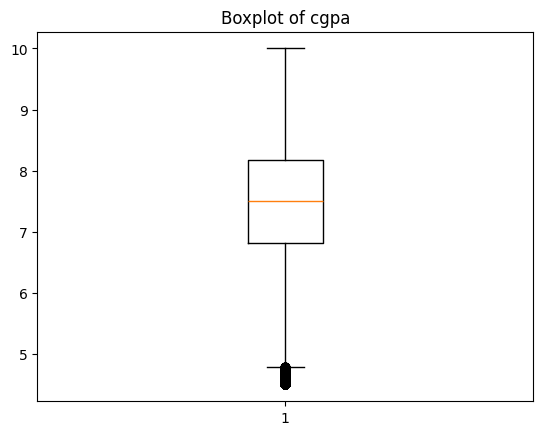

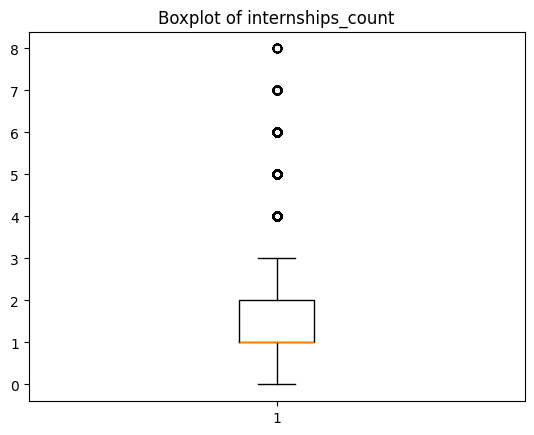

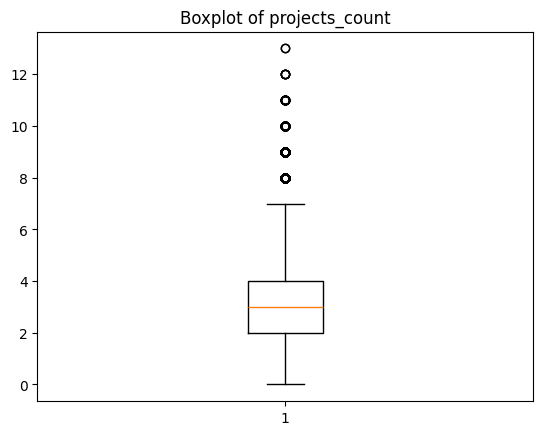

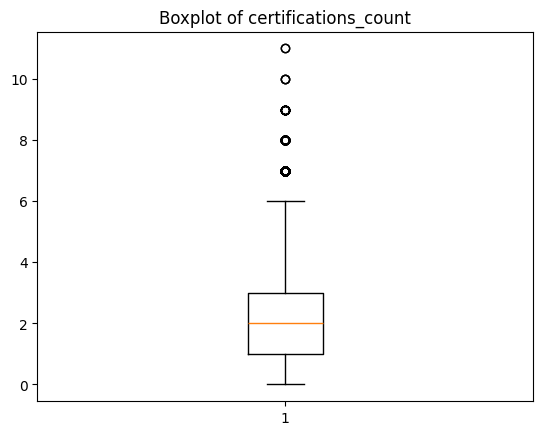

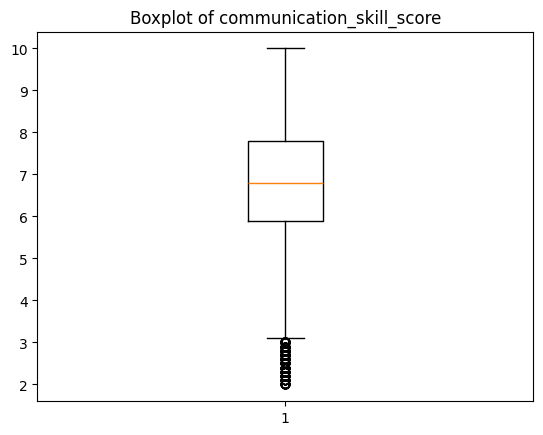

In [160]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [161]:
df.drop(columns=["salary_package_lpa"],inplace=True)
df.to_csv("cleanDF.csv",index=False)